In [1]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob
from torch.utils.data import ConcatDataset, random_split

In [2]:
# Define transformations
class CocoTransform:
    def __call__(self, image, target):
        image = F.to_tensor(image)  # Convert PIL image to tensor
        return image, target

In [3]:
# Dataset class function
def get_coco_dataset(img_dir, ann_file):
    return CocoDetection(
        root=img_dir,
        annFile=ann_file,
        transforms=CocoTransform()
    )

# Define the root directory containing all the folders (each with images and an annotations folder)
photos_root = "photos"

# Lists to store the train and test splits from each folder
train_datasets = []
test_datasets = []

# Iterate over every folder in photos_root
for folder_name in os.listdir(photos_root):
    folder_path = os.path.join(photos_root, folder_name)
    if not os.path.isdir(folder_path):
        continue  # Skip files

    # Construct the path to the annotations folder and search for a JSON file
    ann_folder = os.path.join(folder_path, "annotations")
    json_files = glob.glob(os.path.join(ann_folder, "*.json"))
    if not json_files:
        print(f"Warning: No JSON annotation file found in {ann_folder}. Skipping this folder.")
        continue

    # Use the first JSON file found in the annotations folder
    ann_file = json_files[0]
    
    # Create the COCO dataset for this folder
    dataset = get_coco_dataset(img_dir=folder_path, ann_file=ann_file)
    
    # Check that the dataset is not empty
    dataset_length = len(dataset)
    if dataset_length == 0:
        print(f"Warning: Dataset in {folder_path} is empty. Skipping.")
        continue

    # Compute sizes for an 80/20 train/test split
    test_size = int(0.2 * dataset_length)
    train_size = dataset_length - test_size

    # If the dataset is very small, you might end up with a zero-length test split.
    # You can adjust the split logic here if needed.
    train_split, test_split = random_split(dataset, lengths=[train_size, test_size])

    # Append the splits to the corresponding lists
    train_datasets.append(train_split)
    test_datasets.append(test_split)

# Concatenate all train splits and test splits into two datasets
train_dataset = ConcatDataset(train_datasets)
test_dataset = ConcatDataset(test_datasets)

# Create DataLoaders for the train and test datasets
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,
                          collate_fn=lambda x: tuple(zip(*x)))
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False,
                         collate_fn=lambda x: tuple(zip(*x)))

# (Optional) Print out dataset sizes
print(f"Total training samples: {len(train_dataset)}")
print(f"Total testing samples: {len(test_dataset)}")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Total training samples: 753
Total testing samples: 183


In [4]:
# Load Faster R-CNN with ResNet-50 backbone
def get_model(num_classes):
    # Load pre-trained Faster R-CNN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

In [5]:
# Initialize the model
num_classes = 7 # Background + other
model = get_model(num_classes)

C:\Users\Boyan Ivanov\Documents\FMI\fmi\7th semester\GenerativeAI\Project\FasterRCNN\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Boyan Ivanov\Documents\FMI\fmi\7th semester\GenerativeAI\Project\FasterRCNN\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
# Move model to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# Define optimizer and learning rate scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [8]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    for images, targets in data_loader:
        # Move images to the device
        images = [img.to(device) for img in images]

        # Validate and process targets
        processed_targets = []
        valid_images = []
        for i, target in enumerate(targets):
            boxes = []
            labels = []
            for obj in target:
                # Extract bbox
                bbox = obj["bbox"]  # Format: [x, y, width, height]
                x, y, w, h = bbox

                # Ensure the width and height are positive
                if w > 0 and h > 0:
                    boxes.append([x, y, x + w, y + h])  # Convert to [x_min, y_min, x_max, y_max]
                    labels.append(obj["category_id"])

            # Only process if there are valid boxes
            if boxes:
                processed_target = {
                    "boxes": torch.tensor(boxes, dtype=torch.float32).to(device),
                    "labels": torch.tensor(labels, dtype=torch.int64).to(device),
                }
                processed_targets.append(processed_target)
                valid_images.append(images[i])  # Add only valid images

        # Skip iteration if no valid targets
        if not processed_targets:
            continue

        # Ensure images and targets are aligned
        images = valid_images

        # Forward pass
        loss_dict = model(images, processed_targets)
        losses = sum(loss for loss in loss_dict.values())

        # Backpropagation
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    print(f"Epoch [{epoch}] Loss: {losses.item():.4f}")

In [10]:
import time
import threading

# Define after how many epochs the model should be saved
save_epoch = 5

# Start epoch count at zero
epoch = 0

# A thread that prints the elapsed time every second
class TimerThread(threading.Thread):
    def __init__(self, start_time, stop_event):
        super().__init__()
        self.start_time = start_time
        self.stop_event = stop_event

    def run(self):
        while not self.stop_event.is_set():
            elapsed = time.time() - self.start_time
            # Print elapsed time on the same line
            print(f"\rElapsed time: {elapsed:.1f} seconds", end="")
            time.sleep(1)
        # After stopping, print a newline for clarity
        print()

try:
    # Run training indefinitely until Ctrl+C is pressed
    while True:
        print(f"\nEpoch {epoch + 1} started.")

        # Record the start time and start the timer thread
        start_time = time.time()
        stop_event = threading.Event()
        timer_thread = TimerThread(start_time, stop_event)
        timer_thread.start()

        # Train for one epoch (this call is blocking)
        train_one_epoch(model, optimizer, train_loader, device, epoch)
        
        # Stop the timer thread after training is done
        stop_event.set()
        timer_thread.join()
        
        print(f"Epoch {epoch + 1} finished training.")

        # Step the learning rate scheduler (if applicable)
        lr_scheduler.step()

        # Save the model every 'save_epoch' epochs
        if (epoch + 1) % save_epoch == 0:
            model_path = f"fasterrcnn_resnet50_epoch_{epoch + 1}.pth"
            torch.save(model.state_dict(), model_path)
            print(f"Model saved: {model_path}")

        # Increment epoch counter
        epoch += 1
        print(f"Epoch {epoch} completed.\n")

except KeyboardInterrupt:
    # When Ctrl+C is pressed, save the current state and exit gracefully.
    print("\nTraining interrupted by user. Saving current model state before exiting...")
    model_path = f"fasterrcnn_resnet50_epoch_{epoch + 1}_interrupt.pth"
    torch.save(model.state_dict(), model_path)
    print(f"Model saved: {model_path}")


Epoch 1 started.
Elapsed time: 457.3 secondsEpoch [0] Loss: 0.1246

Epoch 1 finished training.
Epoch 1 completed.


Epoch 2 started.
Epoch [1] Loss: 0.0710conds

Epoch 2 finished training.
Epoch 2 completed.


Epoch 3 started.
Epoch [2] Loss: 0.0383conds

Epoch 3 finished training.
Epoch 3 completed.


Epoch 4 started.
Elapsed time: 487.4 secondsEpoch [3] Loss: 0.0259

Epoch 4 finished training.
Epoch 4 completed.


Epoch 5 started.
Epoch [4] Loss: 0.0390conds

Epoch 5 finished training.
Model saved: fasterrcnn_resnet50_epoch_5.pth
Epoch 5 completed.


Epoch 6 started.
Epoch [5] Loss: 0.0545conds

Epoch 6 finished training.
Epoch 6 completed.


Epoch 7 started.
Epoch [6] Loss: 0.0535conds

Epoch 7 finished training.
Epoch 7 completed.


Epoch 8 started.
Epoch [7] Loss: 0.0274conds

Epoch 8 finished training.
Epoch 8 completed.


Epoch 9 started.
Epoch [8] Loss: 0.0368conds

Epoch 9 finished training.
Epoch 9 completed.


Epoch 10 started.
Epoch [9] Loss: 0.0361conds

Epoch 10 finished

C:\Users\Boyan Ivanov\Documents\FMI\fmi\7th semester\GenerativeAI\Project\FasterRCNN\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Boyan Ivanov\Documents\FMI\fmi\7th semester\GenerativeAI\Project\FasterRCNN\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\Boyan Ivanov\AppData\Local\Temp\ipykernel_7204\187300751.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly

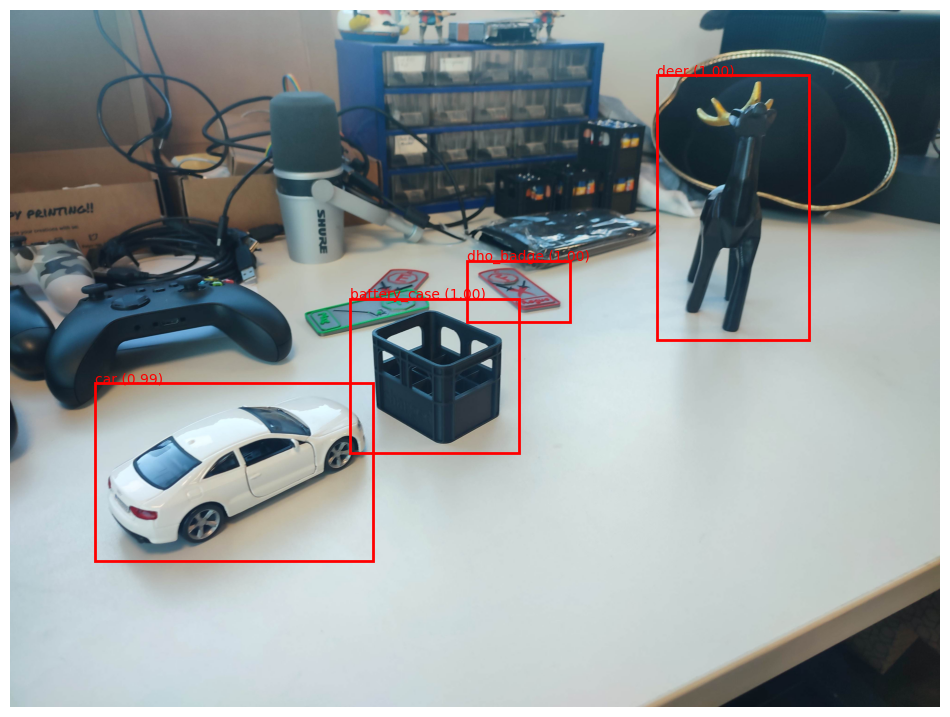

In [1]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
from PIL import Image

# Load Faster R-CNN with ResNet-50 backbone
def get_model(num_classes):
    # Load pre-trained Faster R-CNN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


# Initialize the model
num_classes = 7  # Background + chair + person + table

# Move model to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')


# Load the trained model
model = get_model(num_classes)
model.load_state_dict(torch.load("training2_128_epoch/fasterrcnn_resnet50_epoch_55.pth"))
model.to(device)
model.eval()  # Set the model to evaluation mode


def prepare_image(image_path):
    image = Image.open(image_path).convert("RGB")  # Open image
    image_tensor = F.to_tensor(image).unsqueeze(0)  # Convert image to tensor and add batch dimension
    return image_tensor.to(device)



# Load the unseen image
image_path = "test.jpg"
image_tensor = prepare_image(image_path)

with torch.no_grad():  # Disable gradient computation for inference
    prediction = model(image_tensor)

# `prediction` contains:
# - boxes: predicted bounding boxes
# - labels: predicted class labels
# - scores: predicted scores for each box (confidence level)
COCO_CLASSES = {1: "wallet", 2: "car", 3: "dho_badge", 4: "battery_case", 5: "deer", 6: "skull", 7: "background"}

def get_class_name(class_id):
    return COCO_CLASSES.get(class_id, "Unknown")
    
# Draw bounding boxes with the correct class names and increase image size
def draw_boxes(image, prediction, fig_size=(10, 10)):
    boxes = prediction[0]['boxes'].cpu().numpy()  # Get predicted bounding boxes
    labels = prediction[0]['labels'].cpu().numpy()  # Get predicted labels
    scores = prediction[0]['scores'].cpu().numpy()  # Get predicted scores
    
    # Set a threshold for showing boxes (e.g., score > 0.5)
    threshold = 0.5
    
    # Set up the figure size to control the image size
    plt.figure(figsize=fig_size)  # Adjust the figure size here

    for box, label, score in zip(boxes, labels, scores):
        if score > threshold:
            x_min, y_min, x_max, y_max = box
            class_name = get_class_name(label)  # Get the class name
            plt.imshow(image)  # Display the image
            plt.gca().add_patch(plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                                              linewidth=2, edgecolor='r', facecolor='none'))
            plt.text(x_min, y_min, f"{class_name} ({score:.2f})", color='r')
    
    plt.axis('off')  # Turn off axis
    plt.show()

# Display the image with bounding boxes and correct labels
draw_boxes(Image.open(image_path), prediction, fig_size=(12, 10))  # Example of increased size

In [1]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as F
from PIL import Image
import cv2
import numpy as np

# =============================================================================
# 1. Define the model and load weights
# =============================================================================
def get_model(num_classes):
    # Load pre-trained Faster R-CNN with a ResNet-50 backbone and FPN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    # Get the number of input features for the classifier head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # Replace the pre-trained head with a new one for our custom classes
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# Number of classes (including background if applicable)
num_classes = 7  # Example: Background + 6 object classes

# Set device: use GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Initialize and load the trained model
model = get_model(num_classes)
model.load_state_dict(torch.load("training2_128_epoch/fasterrcnn_resnet50_epoch_55.pth", map_location=device))
model.to(device)
model.eval()  # Set model to evaluation mode

# =============================================================================
# 2. Define class names for detected objects
# =============================================================================
# This dictionary maps your model's label indices to class names.
# Adjust the mapping as needed.
COCO_CLASSES = {
    1: "wallet", 
    2: "car", 
    3: "dho_badge", 
    4: "battery_case", 
    5: "deer", 
    6: "skull", 
    7: "background"  # If your labeling includes background as a class.
}

def get_class_name(class_id):
    return COCO_CLASSES.get(class_id, "Unknown")

# =============================================================================
# 3. Define a function to process a frame from the camera
# =============================================================================
def process_frame(frame, threshold=0.5):
    """
    Given an image frame (BGR from OpenCV), convert it to a PIL image, perform
    object detection, and return the frame with bounding boxes drawn.
    """
    # Convert the frame from BGR (OpenCV default) to RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(frame_rgb)
    
    # Convert the PIL image to a tensor and add a batch dimension
    image_tensor = F.to_tensor(pil_image).unsqueeze(0).to(device)
    
    # Perform inference with no gradient computation
    with torch.no_grad():
        prediction = model(image_tensor)
    
    # Get predicted boxes, labels, and scores
    boxes = prediction[0]['boxes'].cpu().numpy()
    labels = prediction[0]['labels'].cpu().numpy()
    scores = prediction[0]['scores'].cpu().numpy()
    
    # Loop over the predictions and draw those above the threshold
    for box, label, score in zip(boxes, labels, scores):
        if score > threshold:
            # Convert box coordinates to integers
            x_min, y_min, x_max, y_max = box.astype(int)
            class_name = get_class_name(label)
            # Draw rectangle (red color, thickness 2)
            cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), color=(0, 0, 255), thickness=2)
            # Put label text above the rectangle
            text = f"{class_name} ({score:.2f})"
            cv2.putText(frame, text, (x_min, y_min - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
    
    return frame

# =============================================================================
# 4. Capture video from the device camera and perform object detection on each frame
# =============================================================================
def main():
    # Open the default camera (device 0)
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Could not open camera.")
        return

    # Loop over frames from the camera
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Error: Failed to capture frame")
            break

        # Process the frame (perform inference and draw boxes)
        processed_frame = process_frame(frame, threshold=0.5)

        # Display the processed frame
        cv2.imshow("Object Detection - Press 'q' to quit", processed_frame)
        
        # Break the loop if 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Release resources
    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    main()


C:\Users\Boyan Ivanov\Documents\FMI\fmi\7th semester\GenerativeAI\Project\FasterRCNN\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Boyan Ivanov\Documents\FMI\fmi\7th semester\GenerativeAI\Project\FasterRCNN\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\Boyan Ivanov\AppData\Local\Temp\ipykernel_21644\2980502165.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicit

In [9]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
from PIL import Image

# Load Faster R-CNN with ResNet-50 backbone
def get_model(num_classes):
    # Load pre-trained Faster R-CNN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


# Initialize the model
num_classes = 7  # Background + chair + person + table

# Move model to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')


# Load the trained model
model = get_model(num_classes)
model.load_state_dict(torch.load("training2_128_epoch/fasterrcnn_resnet50_epoch_125.pth"))
model.to(device)
model.eval()  # Set the model to evaluation mode


import torch
from torchvision.ops import box_iou

def evaluate_model(model, data_loader, device, iou_threshold=0.5, score_threshold=0.5):
    """
    Evaluates the model on the test data_loader.
    
    For each image:
      - Ground-truth boxes are converted from COCO [x, y, width, height] to [x_min, y_min, x_max, y_max].
      - Predictions with scores lower than score_threshold are ignored.
      - A simple greedy matching is performed using the IoU threshold.
      
    The function prints overall precision, recall, and F1 score.
    """
    model.eval()
    total_true_positives = 0
    total_false_positives = 0
    total_false_negatives = 0

    with torch.no_grad():
        for images, targets in data_loader:
            # Move images to the proper device
            images = [img.to(device) for img in images]
            
            # Run inference
            outputs = model(images)
            
            # Process each image in the batch
            for output, target in zip(outputs, targets):
                # ----- Prepare ground truth boxes -----
                # In your COCO annotations the box is stored as [x, y, width, height].
                gt_boxes = []
                for ann in target:
                    # Some annotations might be filtered during training;
                    # here we assume every annotation in the test target is valid.
                    x, y, w, h = ann["bbox"]
                    gt_boxes.append([x, y, x + w, y + h])
                if len(gt_boxes) > 0:
                    gt_boxes = torch.tensor(gt_boxes, device=device)  # shape: [num_gt, 4]
                else:
                    gt_boxes = torch.empty((0, 4), device=device)
                
                # ----- Process predictions -----
                # The model outputs boxes in [x_min, y_min, x_max, y_max] format.
                pred_boxes = output["boxes"]
                scores = output["scores"]
                # Optionally, filter out predictions with low confidence
                keep = scores >= score_threshold
                pred_boxes = pred_boxes[keep]
                
                # ----- Matching predictions to ground truth -----
                # Greedily match each predicted box to a ground-truth box (if any)
                used_gt = torch.zeros(len(gt_boxes), dtype=torch.bool, device=device)
                true_positives = 0
                false_positives = 0

                if pred_boxes.numel() > 0 and gt_boxes.numel() > 0:
                    # Compute IoU between each predicted box and all ground truth boxes.
                    iou_matrix = box_iou(pred_boxes, gt_boxes)  # shape: [num_preds, num_gt]
                    
                    # For each prediction, check if it overlaps any gt box with IoU >= threshold.
                    for i in range(iou_matrix.shape[0]):
                        ious = iou_matrix[i]
                        max_iou, max_index = ious.max(0)
                        if max_iou >= iou_threshold and not used_gt[max_index]:
                            true_positives += 1
                            used_gt[max_index] = True
                        else:
                            false_positives += 1
                elif pred_boxes.numel() > 0:
                    # If there are predictions but no ground truth, count all as false positives.
                    false_positives += pred_boxes.shape[0]
                
                # Any ground truth boxes that were not matched count as false negatives.
                false_negatives = len(gt_boxes) - used_gt.sum().item()
                
                # Accumulate counts
                total_true_positives += true_positives
                total_false_positives += false_positives
                total_false_negatives += false_negatives

    # Compute precision, recall, and F1 score
    precision = total_true_positives / (total_true_positives + total_false_positives) \
                if (total_true_positives + total_false_positives) > 0 else 0.0
    recall = total_true_positives / (total_true_positives + total_false_negatives) \
             if (total_true_positives + total_false_negatives) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    print("Evaluation results on test set:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")

# Example usage:
# (Assuming your test_loader, model, and device are already defined and the model is in eval mode)
evaluate_model(model, test_loader, device)

C:\Users\Boyan Ivanov\AppData\Local\Temp\ipykernel_16928\3826991455.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("training2_128_epoc

Evaluation results on test set:
  Precision: 0.9796
  Recall:    0.9897
  F1 Score:  0.9846
